In [1]:
%%capture
%run parse_data.ipynb
%run descriptive.ipynb
%run classical.ipynb

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import gridspec
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import tree, preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'<br>{s}'
    else:
        s = f'<br>{s}'
    display( Markdown(s) )

The first step in Machine Learning is to sample the data, typically seperating the training set and the testing set.

For this step, I will use K-Fold methods for both splitting and testing. K-Fold has an advantage of being robust, and less likely to suffer from overfitting from a particular split.

In [3]:
kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

We also need to preprocess the data to have a more reliable results. In this notebook, the method used is normalization. Normalizing data not only helps with removing bias from the model but also helps with regularization.

From the box plots of in descriptive notebook, we can see that Happiness has indications of outliers. However, because the data belongs to Likert scale, it can represent true opinion of some respondents and not considered a mistake. Therefore, I will use min-max normalization.

In [4]:
scaler = MinMaxScaler()

normalized_with_outliers = scaler.fit_transform(df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']])

Our first ML task is to predict which combination of variables will make a respondent a user or a non-user. 

We would use Random Forest and Logistic Regression for the task. The model with better performance would be chosen for the main report.

Let's start with the Random Forest model!

In [5]:
# Splitting into features and the target
X = df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']]
feature = df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']].columns.tolist()
print(feature)

y = df['Status']
target = sorted(df['Status'].unique().astype(str))
print(target)

['P', 'SI', 'SC', 'H', 'NE', 'IBB']
['0', '1']


In [6]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

acc_rf = cross_val_score(rf_model, X, y, cv = kf, scoring = 'accuracy')
pre_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='precision')
rec_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='recall')

trained_rf = rf_model.fit(X, y)

max_acc_rf = max(acc_rf)
max_pre_rf = max(pre_rf)
max_rec_rf = max(rec_rf)

print(f"The highest accuracy score: {max_acc_rf:.2f}")
print(f"The highest precision score: {max_pre_rf:.2f}")
print(f"The highest recall score: {max_rec_rf:.2f}")
print(f"The average accuracy of the model: {np.mean(acc_rf):.2f}")
print(f"The average precision of the model: {np.mean(pre_rf):.2f}")
print(f"The average recall of the model: {np.mean(pre_rf):.2f}")

The highest accuracy score: 0.86
The highest precision score: 0.80
The highest recall score: 0.60
The average accuracy of the model: 0.79
The average precision of the model: 0.60
The average recall of the model: 0.60


While the highest accuracy and precision score has a relatively decent score (over 0.8), the recall score is obviously lower than the others.

I suspect that the problem lies in the dataset, since most of the respondents are non-users, which makes the model less likely to predict a positive instance.

In [7]:
y.value_counts(0)

Status
0    601
1    202
Name: count, dtype: int64

By counting the instances, it confirmed my suspicion. 

While in the progress of tuning the hyperparameters, I found that by setting the max depths to 15 increases the highest recall up to 5%, while reducing the accuracy down only 1%. With the more balanced score, I decided to select this version for the visualizations.

In [8]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42, max_depth=15)

acc_rf = cross_val_score(rf_model, X, y, cv = kf, scoring = 'accuracy')
pre_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='precision')
rec_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='recall')

trained_rf = rf_model.fit(X, y)

max_acc_rf = max(acc_rf)
max_pre_rf = max(pre_rf)
max_rec_rf = max(rec_rf)

print(f"The highest accuracy score: {max_acc_rf:.2f}")
print(f"The highest precision score: {max_pre_rf:.2f}")
print(f"The highest recall score: {max_rec_rf:.2f}")
print(f"The average accuracy of the model: {np.mean(acc_rf):.2f}")
print(f"The average precision of the model: {np.mean(pre_rf):.2f}")
print(f"The average recall of the model: {np.mean(pre_rf):.2f}")

The highest accuracy score: 0.85
The highest precision score: 0.80
The highest recall score: 0.65
The average accuracy of the model: 0.79
The average precision of the model: 0.59
The average recall of the model: 0.59


Let's visualize the first Decision Tree in the Random Forest model into a plot!

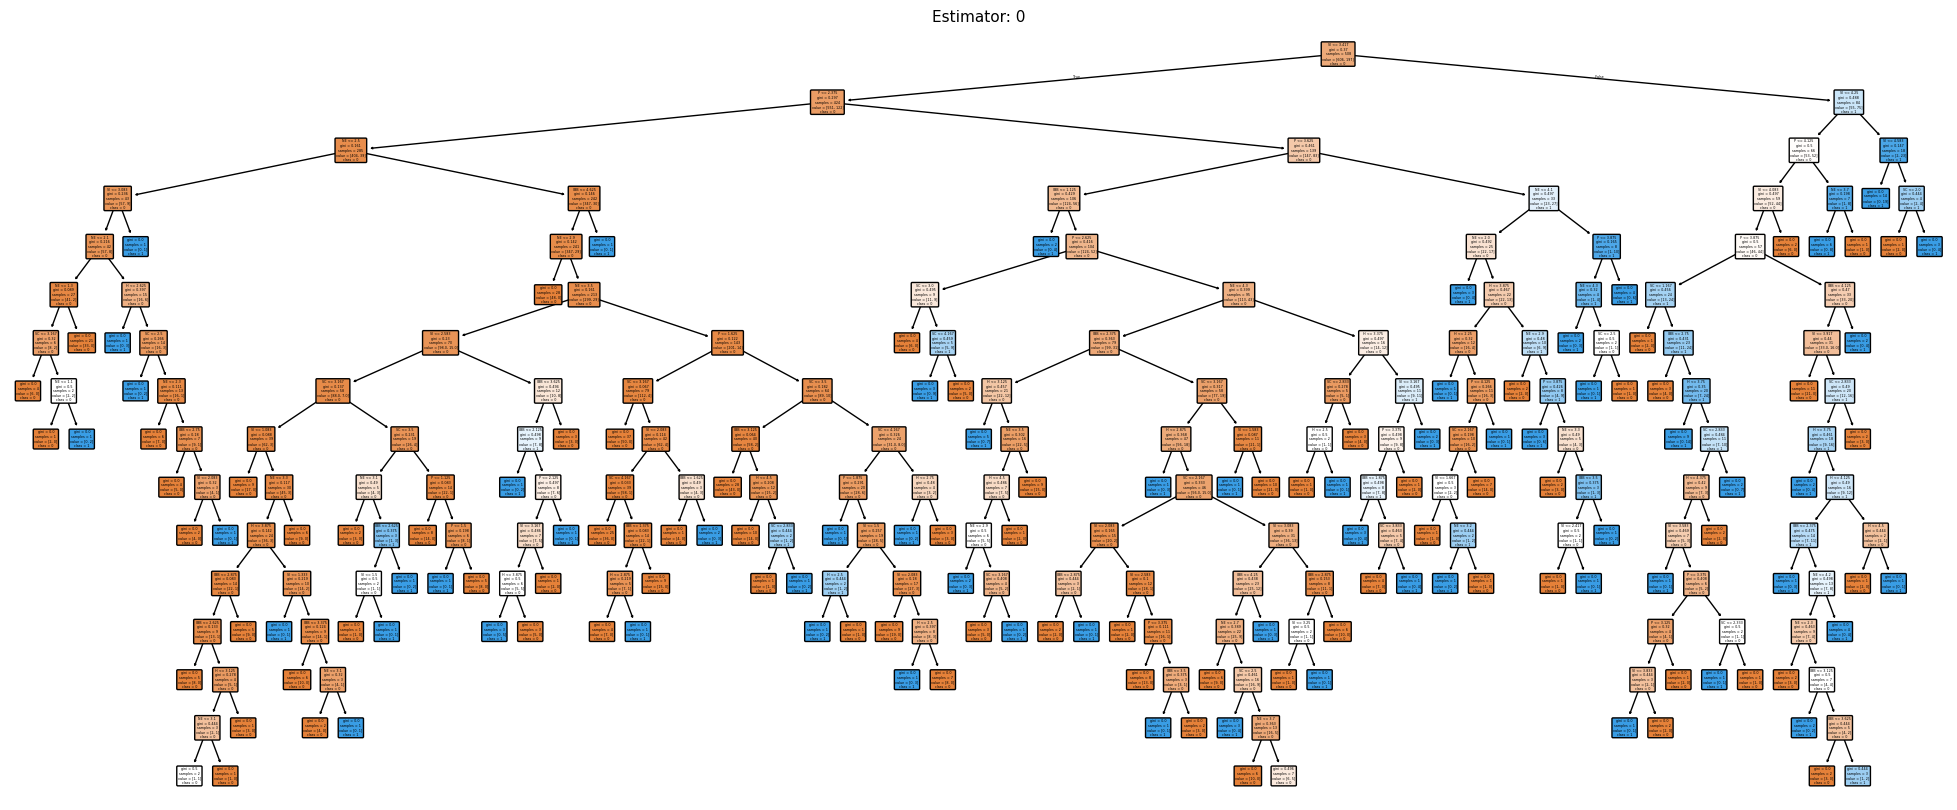

<br><p><span style="font-size: 1.2em;"><b>Figure 0</b>: Visualization of the first Decision Tree in Random Forest model</span></p>

In [9]:
def random_forest_fig():
    plt.figure(figsize = (25,10))
    tree.plot_tree(trained_rf.estimators_[0], feature_names=feature, class_names=target, filled=True, rounded=True)
    plt.title('Estimator: ' + str(0), fontsize = 11)     
    plt.show()

    display_title("Visualization of the first Decision Tree in Random Forest model", pref='Figure', num=0)

random_forest_fig()

Since the Decision Tree has many depths that is hard to read, we will extract the information and find the most important features that the model uses for splitting decision

In [10]:
def random_forest_results():
    display_title("Relevent scores for Random Forest model", pref='Result', num=0)

    acc_rf = cross_val_score(rf_model, X, y, cv = kf, scoring = 'accuracy')
    pre_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='precision')
    rec_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='recall')

    max_acc_rf = max(acc_rf)
    max_pre_rf = max(pre_rf)
    max_rec_rf = max(rec_rf)

    print(f"The highest accuracy score: {max_acc_rf:.2f}")
    print(f"The highest precision score: {max_pre_rf:.2f}")
    print(f"The highest recall score: {max_rec_rf:.2f}")
    print(f"The average accuracy of the model: {np.mean(acc_rf):.2f}")
    print(f"The average precision of the model: {np.mean(pre_rf):.2f}")
    print(f"The average recall of the model: {np.mean(pre_rf):.2f}")
    
    display_title("Features' importance and the Top 3 most important features", pref='Table', num=0)
    # extracting the importance score from the model
    importances = trained_rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature, 'Importance': importances})

    # ranking the importance score
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending = False)
    display(feature_importance_df)

    # top 3 importance features
    top_3 = list(feature_importance_df['Feature'][:3].values)
    print(f"Top 3 most importance features: {top_3}")
    
random_forest_results()

<br><p><span style="font-size: 1.2em;"><b>Result 0</b>: Relevent scores for Random Forest model</span></p>

The highest accuracy score: 0.85
The highest precision score: 0.80
The highest recall score: 0.65
The average accuracy of the model: 0.79
The average precision of the model: 0.59
The average recall of the model: 0.59


<br><p><span style="font-size: 1.2em;"><b>Table 0</b>: Features' importance and the Top 3 most important features</span></p>

,Feature,Importance
0,P,0.268764
1,SI,0.181253
4,NE,0.160502
5,IBB,0.150353
2,SC,0.120346
3,H,0.118782


Top 3 most importance features: ['P', 'SI', 'NE']


We will try to predict with a Logistic Regression model this time! During the working process, I found out that using L1 Regularization would return the best results. Let's see its performance!

<br><p><span style="font-size: 1.2em;"><b>Figure 1</b>: Logistic Regression model's performance in predicting User Status</span></p>

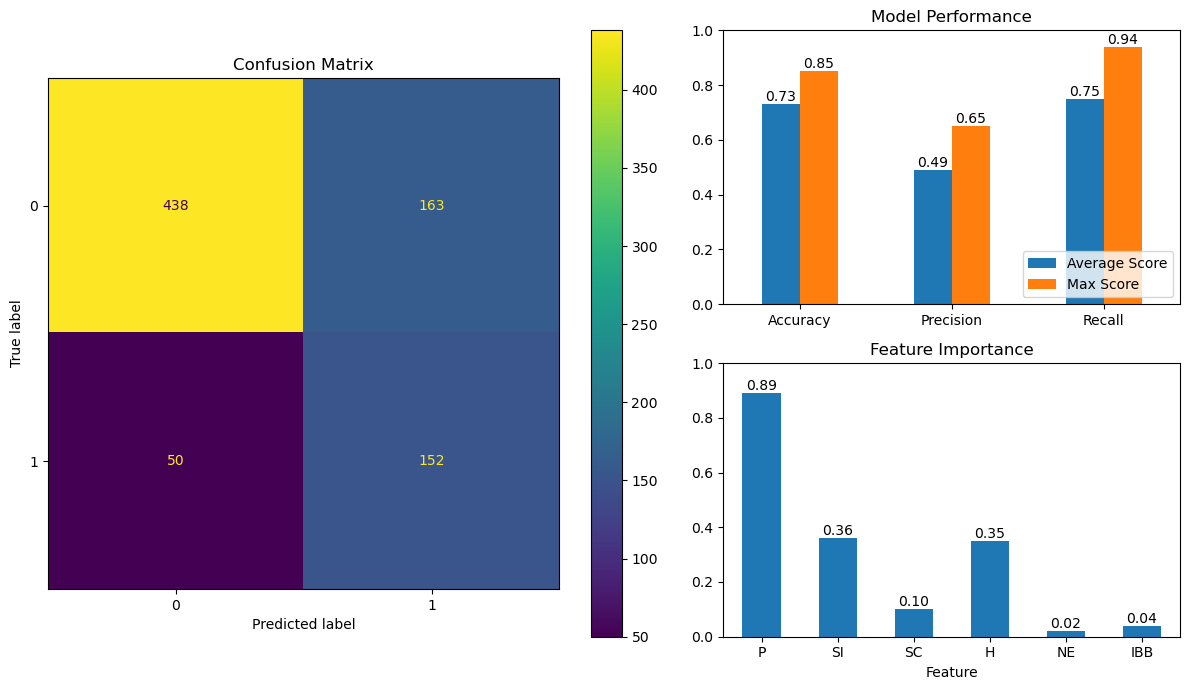

In [11]:
LG_model_L1 = LogisticRegression(penalty='l1', random_state=42, solver='liblinear', class_weight='balanced')

LG_acc_L1_outlier = cross_val_score(LG_model_L1, X, y, cv = kf, scoring='accuracy')
LG_pre_L1_outlier = cross_val_score(LG_model_L1, X, y, cv = kf, scoring='precision')
LG_rec_L1_outlier = cross_val_score(LG_model_L1, X, y, cv = kf, scoring='recall')

def L1_LG_results():
    # scores for model
    table = pd.DataFrame(index=["Accuracy", "Precision", "Recall"])
    table["Average Score"] = [np.mean(LG_acc_L1_outlier), np.mean(LG_pre_L1_outlier), np.mean(LG_rec_L1_outlier)]
    table["Max Score"] = [np.max(LG_acc_L1_outlier), np.max(LG_pre_L1_outlier), np.max(LG_rec_L1_outlier)]
    table = table.round(2)

    # feature coefficient table
    LG_model_L1.fit(X, y)
    coefficients = LG_model_L1.coef_[0]
    abs_coefficients = abs(LG_model_L1.coef_[0])
    feature_coefficient = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients, 'Absolute Coefficient': abs_coefficients})
    feature_coefficient = feature_coefficient.round(2)

    # confusion matrix
    y_predict = cross_val_predict(LG_model_L1, X, y, cv = kf)
    cm = confusion_matrix(y, y_predict)
    model_cm_visual = ConfusionMatrixDisplay(cm)

    # create a plot with gridspec to plot all tables and the confusion matrix
    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1.4, 1])
    
    ax_cm = fig.add_subplot(gs[:,0])
    model_cm_visual.plot(ax=ax_cm)
    ax_cm.set_title("Confusion Matrix")

    ax_score = fig.add_subplot(gs[0,1])
    table.plot(kind="bar", ax=ax_score)
    ax_score.tick_params(axis = 'x', labelrotation = 0)
    ax_score.set_title("Model Performance")
    ax_score.legend(loc="lower right")
    ax_score.set_ylim(0, 1)
    for container in ax_score.containers:
        ax_score.bar_label(container, fmt="%.2f")

    ax_feat = fig.add_subplot(gs[1, 1])
    feature_coefficient.set_index("Feature")["Absolute Coefficient"].plot(kind="bar", ax=ax_feat)
    ax_feat.set_ylim(0, 1)
    ax_feat.tick_params(axis = 'x', labelrotation = 0)
    ax_feat.set_title("Feature Importance")
    for value in ax_feat.containers:
        ax_feat.bar_label(value, fmt="%.2f")
    
    display_title("Logistic Regression model's performance in predicting User Status", pref='Figure', num=1)
    plt.tight_layout()
    plt.show()

L1_LG_results()

Although the Logistic Regression has a lower precision score, the recall score is much better compared to the Random Forest model.

From the business perspective, recall score would have higher importance because it resembles closer with their customer base. Missing a false negative user respondent is much more costly for business than identify a false positive non-user. Therefore, Logistic Regression would be the more relevant model.

Comparing the feature importance result of 2 models, while Promotion and Social Influence are the most influential features in both models, the Logistic Regression model has Happiness as the third most instead of Normative Evaluation in Random Forest model.

Given the higher recall score of the Logistic Regression model, we can infer that the Happiness provides stronger signal to differentiate users and non-users rather than relying more heavily on Normative Evaluation and other features not in top 3 for this model.

---

While User status determines the customer base of the BNPL service, the Impulsive Buying Behavior (IBB) tells how much a customer is willing to spend their money on the service. Therefore, we will also plot a predict regression for the IBB score.

We will first try with a KNN Regression model

In [12]:
X_reg = df[['P', 'SI', 'SC', 'H', 'NE']]
feature = df[['P', 'SI', 'SC', 'H', 'NE']].columns.tolist()
print(feature)

y_reg = df['IBB']
target = sorted(df['IBB'].unique().astype(str))
print(target)

['P', 'SI', 'SC', 'H', 'NE']
['1.0', '1.25', '1.5', '1.75', '2.0', '2.25', '2.5', '2.75', '3.0', '3.25', '3.5', '3.75', '4.0', '4.25', '4.5', '4.75', '5.0']


During the process of feature selection, I found the result of the model got worse, so I reverted to the orginal model and tune the hyperparameters inside it instead

In [13]:
param_grid = {'n_neighbors': [30, 40, 50, 58, 70, 90, 120], 'weights': ['distance', 'uniform'], 'p': [1, 2], 'metric': ['manhattan', 'cosine', 'euclidean']}

k_try = KNeighborsRegressor()
grid_search_rmse = GridSearchCV(k_try, param_grid, cv = kf, scoring = 'neg_root_mean_squared_error', n_jobs=-1)
grid_search_r2 = GridSearchCV(k_try, param_grid, cv = kf, scoring = 'r2', n_jobs=-1)
grid_search_rmse.fit(X_reg, y_reg)
grid_search_r2.fit(X_reg, y_reg)
print("Best params:", grid_search_rmse.best_params_)
print("Best CV RMSE:", -grid_search_rmse.best_score_)
print("Best R2 score", grid_search_r2.best_score_)

Best params: {'metric': 'manhattan', 'n_neighbors': 70, 'p': 1, 'weights': 'distance'}
Best CV RMSE: 0.7369536674698293
Best R2 score 0.2850510425368048


A RMSE score of 0.7369 is a reasonable score compared to the scale of the actual data (1-5). For example, if the predicted score for IBB is 4, the range of the actual data should be 4 ± 0.7369. However, the R² score being ~0.28 means the model has weak predictive power in explaining the variance of the target data.

Given the characteristics of Likert Scale data, we will try the RandomForestRegressor model. The model is said to be able handle weak signals and data that suffer from multicollinearity like that of our dataset, so let's try using it to see if it performs better.

In [14]:
from scipy.stats import randint

RFregressor = RandomForestRegressor(random_state=42)

param_rf = {
    'n_estimators': randint(50, 120),
    'max_depth': randint(5,20),
    'min_samples_split': randint(2,20),
    'min_samples_leaf': randint(2,20),
    'oob_score': [True, False]}

RF_rmse = RandomizedSearchCV(estimator=RFregressor, n_iter=30, param_distributions=param_rf, cv = kf, scoring = 'neg_root_mean_squared_error')
RF_R2 = RandomizedSearchCV(estimator=RFregressor, n_iter=30, param_distributions=param_rf, cv = kf, scoring = 'r2')

RF_rmse.fit(X_reg, y_reg)
RF_R2.fit(X_reg, y_reg)

print("Best parameters:", RF_rmse.best_params_)
print("Best CV RMSE:", -RF_rmse.best_score_)
print("Best CV R2:", RF_R2.best_score_)

Best parameters: {'max_depth': 9, 'min_samples_leaf': 19, 'min_samples_split': 4, 'n_estimators': 52, 'oob_score': True}
Best CV RMSE: 0.7255706039298017
Best CV R2: 0.3062853873842218


Using K-Fold cross-validation, we can see that the Random Forest Regressor model performed better than the K Neighbor Regression model.

We will use the trained Random Forest Regressor model for visualization.

In [15]:
RFregressor_optimized = RandomForestRegressor(max_depth=16, min_samples_leaf=17, min_samples_split=10, n_estimators=75, oob_score=False, random_state=42)

trained_RFregressor = RFregressor_optimized.fit(X_reg, y_reg)

features_rf = X_reg.columns.tolist()

<br><p><span style="font-size: 1.2em;"><b>Figure 2</b>: Random Forest Regressor model's performance in predicting Impulsive Buying Behavior score</span></p>

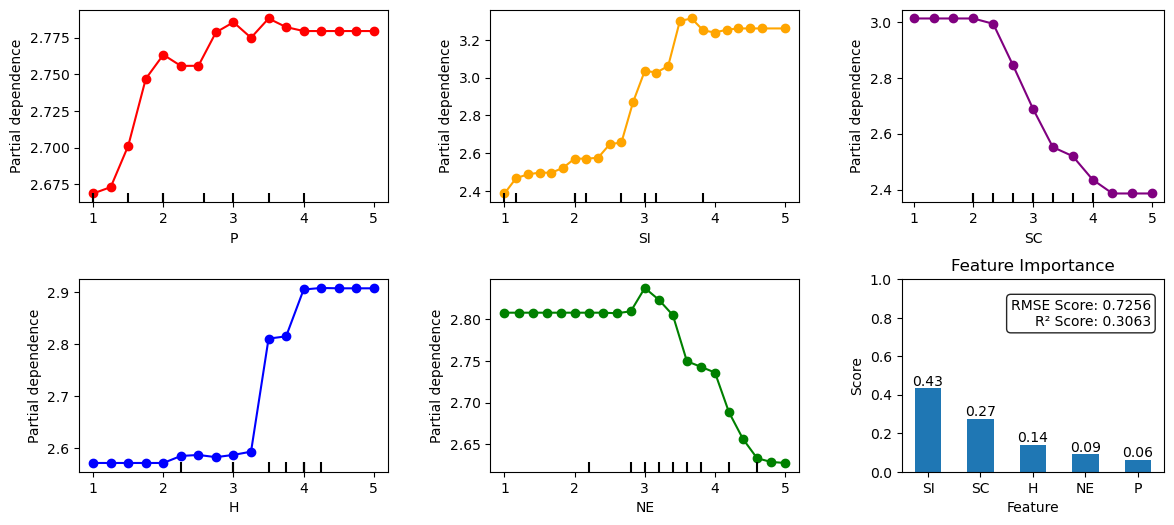

In [16]:
from sklearn.inspection import PartialDependenceDisplay

def RandomForestRegressor_results():
    # most important feature table
    importances = trained_RFregressor.feature_importances_
    feature_importance_rf = pd.DataFrame({'Feature': features_rf, 'Importance': importances})
    feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending = False)

    # Relevant results of the model
    RF_model_result = pd.DataFrame(index=['RMSE', 'R² Score'])
    RF_model_result['Scores'] = [-RF_rmse.best_score_, RF_R2.best_score_]
    RF_model_result = RF_model_result.round(4)

    # create a plot with gridspec to plot all tables and plots of the model
    fig_rf = plt.figure(figsize=(14, 6))
    gs_rf = gridspec.GridSpec(2, 3, width_ratios=[2, 2, 1.7], height_ratios=[1,1], wspace=0.35, hspace=0.4)
    
    for i, feature_idx in enumerate(range(5)):
        row = (i//3)
        col = i % 3
        colors = ['red', 'orange', 'purple', 'blue', 'green']
        ax_plot_rf = fig_rf.add_subplot(gs_rf[row,col])
        PartialDependenceDisplay.from_estimator(estimator=trained_RFregressor, X=X_reg, features=[feature_idx],
                                                feature_names=features_rf, kind='average', ax=ax_plot_rf,
                                                line_kw={'color': colors[i], 'marker': 'o'})
        ax_plot_rf.set_xlabel(f"{feature_importance_rf.columns}")
        ax_plot_rf.set_ylim(2, 4)
        ax_plot_rf.set_ylabel("Predicted IBB score")

    # top features plot
    ax_feat = fig_rf.add_subplot(gs_rf[1,2])
    feature_importance_rf.set_index("Feature")["Importance"].plot(kind="bar", ax=ax_feat)
    ax_feat.set_ylim(0, 1)
    ax_feat.set_title("Feature Importance")
    text = (f"RMSE Score: {RF_model_result.loc['RMSE', 'Scores']:.4f}\n"
            f"R² Score: {RF_model_result.loc["R² Score", "Scores"]:.4f}")
    ax_feat.text(0.95, 0.9, text, transform = ax_feat.transAxes, fontsize = 10,
                 ha = 'right', va = 'top', bbox = dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_feat.set_ylabel("Score")
    ax_feat.tick_params(axis = 'x', labelrotation = 0)
    for value in ax_feat.containers:
        ax_feat.bar_label(value, fmt="%.2f")
    
    display_title("Random Forest Regressor model's performance in predicting Impulsive Buying Behavior score", pref='Figure', num=2)
    plt.show()

RandomForestRegressor_results()